# Detecting LLM-Generated Student Essays with Transformer Fine-Tuning and Robustness Analysis

## roBERTa LoRA Fine-tuning: Feature-Based Classification & Data Ablations

**Team:** Joseph Souaiby & Huzaifah Wasima

**Dataset:** [Kaggle LLM Detect AI Generated Text](https://www.kaggle.com/datasets/sunilthite/llm-detect-ai-generated-text-dataset) (~28k labeled essays)

In [1]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.8 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


## Data Preprocessing

In [2]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import itertools

from datasets import Dataset
from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModel

import torch
from torch import nn
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader

import re
import string
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
from peft import get_peft_model, LoraConfig

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", palette="muted")
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

from google.colab import drive
drive.mount('/content/drive')

Using cuda device
Mounted at /content/drive


In [3]:
DATA_PATH = "data/Training_Essay_Data.csv"
RAID_120_PATH="/content/drive/MyDrive/raid_120k.csv"
RAID_1000_PATH="/content/drive/MyDrive/raid_1M.csv"
SEED = 42
MIN_CHARS = 50
LABEL_NAMES = {0: "Human", 1: "AI"}

In [4]:
def normText(text):
    text= re.sub(r"\s+", " ", text)
    return text.strip()


def balanceClasses(df, class_weight, total_samples=10000, lab_col_name='label'):
  temps=[]
  for label, weight in class_weight.items():
    samps=int(weight*total_samples)
    temp=df[df[lab_col_name] == label].sample(samps, random_state=SEED)
    temps.append(temp)
  balance_df = pd.concat(temps).reset_index(drop=True)
  return balance_df

def cleanData(df=None, path= DATA_PATH, text_col_name="text",label_col_name="generated") -> pd.DataFrame:
    if path != None:
      df =pd.read_csv(path)
    else:
      df=df
    df= df.rename(columns={text_col_name: "text", label_col_name: "label"})
    df["label"]= df["label"].astype(int)
    df["label_name"]=df["label"].map(LABEL_NAMES)
    df["text"]= df["text"].map(normText)
    df= df[df["text"].str.len() >= MIN_CHARS].copy()

    n_prev= len(df)

    df= df.drop_duplicates(subset="text").reset_index(drop=True)
    n_new= len(df)


    if n_prev!= n_new:
        print(f"Removed {n_prev - n_new} duplicate essays.")
    print(f"Dataset size after cleaning: {len(df):,} essays")
    print(f"Label distribution:\n{df['label'].value_counts().to_string()}\n")
    print(f"Data Sample: {df.head(5)}")
    return df

def splitData(df,val_size,test_size):
    train_val, test = train_test_split(df,test_size=test_size,stratify=df["label"],random_state=SEED)
    adj_val= val_size/(1.0 - test_size)
    train,val= train_test_split(train_val,test_size=adj_val,stratify=train_val["label"],random_state=SEED)
    print(f"Split sizes — train: {len(train):,}  val: {len(val):,}  test: {len(test):,}")
    return train, val, test

def getSplits(path= DATA_PATH,val_size= 0.1,test_size= 0.1):
    df = cleanData(path)
    train,val,test=splitData(df, val_size=val_size,test_size=test_size)

    X_train=train["text"].tolist()
    y_train=train["label"].tolist()

    X_val=val["text"].tolist()
    y_val=val["label"].tolist()

    X_test=test["text"].tolist()
    y_test=test["label"].tolist()
    return X_train, X_val, X_test, y_train, y_val, y_test

def streamRAID(num_samples, save_path):
    raid=load_dataset("liamdugan/raid", split="train", streaming=True)
    samples = list(itertools.islice(raid, num_samples))
    raid_df=pd.DataFrame.from_dict(samples)[['model','generation']]
    raid_df.to_csv(save_path)

### Data Preprocessing Pipeline for PyTorch

In [5]:
def DataLoaderPipeline(csv_path,
                       use_cols,
                       tokenizer,
                       format_cols,
                       batch_size,
                       collator,
                       num_workers,
                       split=True,
                       val_size=0.1,
                       test_size=0.2,
                       balance_data=False,
                       balancer_kwargs=None,
                       binarize_label=False,
                       label_col='generated',
                       text_col='text',
                       human_label='human'):


  df=pd.read_csv(csv_path)

  if binarize_label:
    df[label_col]=df[label_col].apply(lambda x: 0 if x==human_label else 1)

  df=cleanData(df=df, path=None, text_col_name=text_col, label_col_name=label_col)

  if balance_data:
    assert balancer_kwargs != None, "Please provide balancer_kwargs"
    df=balanceClasses(df, class_weight=balancer_kwargs['class_weight'], total_samples=balancer_kwargs['total_samples'])

  if split:
    assert val_size>0 and test_size>0, "Give valid val and test sizes"
    train, val, test=splitData(df, val_size=val_size, test_size=test_size)

    train=Dataset.from_pandas(train[use_cols], preserve_index=False)
    val=Dataset.from_pandas(val[use_cols], preserve_index=False)
    test=Dataset.from_pandas(test[use_cols], preserve_index=False)

    train=train.map(tokenizer, batched=True)
    val=val.map(tokenizer, batched=True)
    test=test.map(tokenizer, batched=True)

    train.set_format("torch", columns=format_cols)
    val.set_format("torch", columns=format_cols)
    test.set_format("torch", columns=format_cols)

    train_loader=DataLoader(train, batch_size=batch_size, shuffle=True, collate_fn=collator, num_workers=num_workers)
    val_loader=DataLoader(val, batch_size=batch_size, shuffle=False, collate_fn=collator, num_workers=num_workers)
    test_loader=DataLoader(test, batch_size=batch_size, shuffle=False, collate_fn=collator, num_workers=num_workers)

    return train_loader, val_loader, test_loader

  df=Dataset.from_pandas(df[use_cols], preserve_index=False)
  df=df.map(tokenizer, batched=True)
  df.set_format("torch", columns=format_cols)
  return DataLoader(df, batch_size=batch_size, shuffle=False, collate_fn=collator, num_workers=num_workers)


## IMPORTANT

- Run only once ever

In [ ]:
streamRAID(120000, save_path=RAID_120_PATH)
streamRAID(1000000, save_path=RAID_1000_PATH)

## Exploratory Data Analysis

### Class Distribution
Label balance between student-written (0) and AI-generated (1) essays.

### Text Length Analysis
Word count and character count distributions by class, including summary statistics and visual comparisons.

### Vocabulary & Stylistic Metrics
Type-token ratio, average word length, and average sentence length broken down by class.

### Top Frequent Terms
Most common unigrams and bigrams per class (stopwords removed) to identify potential prompt leakage or formatting artifacts.

### Punctuation & Structural Patterns
Comparison of punctuation frequency, paragraph counts, and formatting differences between human and AI-generated essays.



#### Helper Functions

In [6]:
def save(fig, name, dir="results/eda_kaggle"):
    dir = Path(dir)
    dir.mkdir(parents=True, exist_ok=True)
    path = dir / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)

def wordCount(text):
    return len(text.split())

def charCount(text):
    return len(text)

def avgWordLength(text):
    words = text.split()
    if words:
      return np.mean([len(w) for w in words])
    return 0.0

def avgSentenceLength(text):
    sentences = re.split(r"[.!?]+", text)
    res=[]
    for s in sentences:
      if s.strip():
        res.append(s.strip())
    if not sentences:
        return 0.0
    return np.mean([len(s.split()) for s in sentences])


def typeTokenRatio(text):
    tokens = text.lower().split()
    if tokens:
      return len(set(tokens))/len(tokens)
    return 0.0

def paragraphCount(text):
    res=[]
    for p in text.split("\n"):
      if p.strip():
        res.append(p)
    return max(1, len(res))

def punctuationFreq(text):
    n_punct=0
    for c in text:
      if c in string.punctuation:
        n_punct+=1
    return (n_punct / len(text) * 100) if text else 0.0

def topUgrams(texts, n= 1, top_k= 20):
    stop =ENGLISH_STOP_WORDS
    cntr: Counter = Counter()
    for text in texts:
      toks= re.findall(r"\b[a-z]+\b", text.lower())
      tokens=[]
      for t in toks:
        if t not in stop and len(t)>2:
          tokens.append(t)
      cntr.update(tokens)
    return cntr.most_common(top_k)

def topBgrams(texts, top_k=20):
  stop=ENGLISH_STOP_WORDS
  cntr: Counter = Counter()
  for text in texts:
    toks= re.findall(r"\b[a-z]+\b", text.lower())
    tokens=[]
    for t in toks:
      if t not in stop and len(t)>2:
        tokens.append(t)
    cntr.update(zip(tokens, tokens[1:]))
  return cntr.most_common(top_k)


def makeHistogram(data, save_path, f_name, bins=60, x_label=None, y_label="Count", suptitle=None, show=True):
    groups = list(data)
    num_plots = len(groups)
    fig, axes = plt.subplots(1, num_plots, figsize=(5.5 * num_plots, 4))

    if num_plots == 1:
        axes = [axes]

    for i, (name, grp) in enumerate(groups):
        axes[i].hist(grp, bins=bins)
        axes[i].set_title(name)
        axes[i].set_ylabel(y_label)
        if x_label:
            axes[i].set_xlabel(x_label)
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    if show:
      plt.show()
    save(fig, f_name, save_path)

def makeBoxPlot(df, data, col_name, suptitle, save_path, f_name, show=True):
  num_cols=len(data)
  fig, axes= plt.subplots(1, num_cols, figsize=(5*num_cols, 4))
  if num_cols == 1:
        axes = [axes]
  for ax,(label, (col, _)) in zip(axes, data.items()):
      sns.boxplot(data=df,x=col_name,y=col,hue=col_name,legend=False,ax=ax, showfliers=False)
      ax.set_title(label)
      ax.set_xlabel("")
  fig.suptitle(suptitle)
  plt.tight_layout()
  if show:
    plt.show()
  save(fig,f_name,  save_path)

def runAnalysis(df):
  df["word_count"] = df["text"].map(wordCount)
  df["char_count"] = df["text"].map(charCount)
  df["ttr"]=df["text"].map(typeTokenRatio)
  df["avg_word_len"]=df["text"].map(avgWordLength)
  df["avg_sent_len"]=df["text"].map(avgSentenceLength)
  df["punct_freq"]=df["text"].map(punctuationFreq)
  df["para_count"]=df["text"].map(paragraphCount)
  return df



### Code for EDA Plots


#### Class Distribution
Label balance between student-written (0) and AI-generated (1) essays.

In [7]:
def plotClassDist(df, f_name, save_path='results/eda_kaggle'):
    print("\n[1] Class distribution")
    counts= df["label"].value_counts().sort_index()
    pcts =counts / counts.sum() * 100
    tbl =pd.DataFrame({"Count": counts, "Percentage": pcts.round(2)})
    tbl.index= tbl.index.map(LABEL_NAMES)
    print(tbl.to_string())
    fig,ax= plt.subplots(figsize=(5, 4))
    labels=[]
    colors=[]
    for i in counts.index:
      labels.append(LABEL_NAMES[i])
    heights= counts.values
    bars =ax.bar(labels,heights)
    ax.set_title("Class Distribution")
    ax.set_ylabel("Number of Essays")

    plt.show()
    save(fig, f_name, save_path)

#### Text Length Analysis
Word count and character count distributions by class, including summary statistics and visual comparisons.

In [8]:
def plotLengthAnalysis(df, f_name,save_path='results/eda_kaggle'):
    print("\n[2] Text length analysis")
    word_stats=(df.groupby("label_name")["word_count"].agg(["mean", "median", "min", "max", "std"]).round(1))
    char_stats=(df.groupby("label_name")["char_count"].agg(["mean", "median", "min", "max", "std"]).round(1))
    stats={"Word Count": ("word_count",word_stats),"Character Count": ("char_count",char_stats)}
    for label, (col,metric) in stats.items():
        print(f"\n{label} stats:\n{metric.to_string()}")
    wc=df.groupby("label_name")["word_count"]
    cc=df.groupby("label_name")["char_count"]

    makeHistogram(wc,f_name=f"{f_name}_01", save_path=save_path, bins=60,x_label="Word Count", suptitle="Word Count Distribution by Class")
    makeHistogram(cc,f_name=f"{f_name}_02", save_path=save_path, bins=60,x_label="Character Count", suptitle="Character Count Distribution by Class")

    makeBoxPlot(df, stats, "label_name", suptitle="Length Metrics by Class", save_path=save_path, f_name=f"{f_name}_03")

#### Vocabulary & Stylistic Metrics
Type-token ratio, average word length, and average sentence length broken down by class.

In [9]:
def plotVocabMetrics(df, f_name,save_path='results/eda_kaggle'):
    print("\n[3] Vocabulary metrics")
    ttr_stats=df.groupby("label_name")["ttr"].agg(["mean","median","min","max","std"]).round(3)
    word_stats=df.groupby("label_name")["avg_word_len"].agg(["mean","median","min","max","std"]).round(3)
    sent_stats=df.groupby("label_name")["avg_sent_len"].agg(["mean","median","min","max","std"]).round(3)
    stats= {"Type-Token Ratio":("ttr", ttr_stats),"Avg Word Length (chars)":("avg_word_len", word_stats),"Avg Sentence Length (words)": ("avg_sent_len", sent_stats)}
    for label, (col, metric) in stats.items():
        print(f"\n{label} stats:\n{metric.to_string()}")
    makeBoxPlot(df, stats, "label_name", suptitle="Vocabulary Metrics by Class", save_path=save_path, f_name=f_name)

#### Top Frequent Terms
Most common unigrams and bigrams per class (stopwords removed) to identify potential prompt leakage or formatting artifacts.

In [10]:
def plotTopTermsUnigram(df,f_name, save_path='results/eda_kaggle'):
    fig, axes =plt.subplots(1, 2, figsize=(14, 5))
    for ax, (l_id, l_name) in zip(axes, LABEL_NAMES.items()):
        t= df[df["label"] == l_id]["text"].tolist()
        prs =topUgrams(t, top_k=20)
        trm=[p[0] for p in prs]
        cnts= [p[1] for p in prs]
        y =list(range(len(trm)))
        ax.barh(y,cnts)
        ax.set_yticks(y)
        ax.set_yticklabels(trm)
        ax.invert_yaxis()
        ax.set_title(l_name)
        ax.set_xlabel("Frequency")
    fig.suptitle(f"Top 20 {"unigram".capitalize()} per Class")
    plt.tight_layout()
    plt.show()
    save(fig, f_name, save_path)

In [11]:
def plotTopTermsBigram(df,f_name, save_path='results/eda_kaggle'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (l_id, l_name) in zip(axes, LABEL_NAMES.items()):
        t= df[df["label"] == l_id]["text"].tolist()
        prs= topBgrams(t, top_k=20)
        trm= [" ".join(p[0]) for p in prs]
        cnts= [p[1] for p in prs]
        y_pos= list(range(len(trm)))
        ax.barh(y_pos, cnts)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(trm)
        ax.invert_yaxis()
        ax.set_title(l_name)
        ax.set_xlabel("Frequency")
    fig.suptitle(f"Top 20 {"Bigram".capitalize()} per Class")
    plt.tight_layout()
    plt.show()
    save(fig, f_name, save_path)

#### Punctuation & Structural Patterns
Comparison of punctuation frequency, paragraph counts, and formatting differences between human and AI-generated essays.

In [12]:
def plotFormatting(df,f_name, save_path='results/eda_kaggle'):
    print("\n[5] Punctuation and formatting")
    punc_stats=df.groupby("label_name")['punct_freq'].agg(["mean", "median", "std"]).round(3)
    para_stats= df.groupby("label_name")['para_count'].agg(["mean", "median", "std"]).round(3)
    stats={"Punctuation per 1000 chars":("punct_freq", punc_stats),"Paragraph Count":("para_count", para_stats)}
    for label, (col, metric) in stats.items():
        print(f"\n{label} stats:\n{metric.to_string()}")
    makeBoxPlot(df, stats, "label_name", suptitle="Punctuation and Formatting by Class", save_path=save_path, f_name=f"{f_name}_box")
    puncts=[".", ",", "!", "?", ";", ":", '"', "'", "-"]
    rows = []
    for l_id, l_name in LABEL_NAMES.items():
        texts = " ".join(df[df["label"]==l_id]["text"].tolist())
        total_chars = len(texts)
        for ch in puncts:
            rows.append({"Class": l_name,"Punctuation": ch,"Per 1000 chars": texts.count(ch)/ total_chars * 1000})
    punc_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=punc_df, x="Punctuation", y="Per 1000 chars", hue="Class",ax=ax)
    ax.set_title("Punctuation per 1000 Characters")
    ax.set_xlabel("Punctuation Character")
    plt.tight_layout()
    plt.show()
    save(fig, f_name, save_path)

### Metrics
- Accuracy
- Recall
- Precision
- F1-Score
- Confusion Matrix

In [35]:
def genMetrics(y_test, pred, y_proba, save_path):
  print(f"Accuracy= {accuracy_score(y_test, pred)*100:.2f}%")
  print(classification_report(y_test, pred))


  fig,(ax1,ax2)= plt.subplots(1, 2, figsize=(12, 4.5))

  ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Human", "AI"], cmap="Blues", normalize='true', ax=ax1)
  ax1.grid(False)
  ax1.set_title("Confusion Matrix")

  y_score = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
  RocCurveDisplay.from_predictions(y_test, y_score, ax=ax2)
  ax2.grid(False)
  ax2.set_title("ROC Curve")

  plt.tight_layout()
  plt.show()

  fig_cm, ax_cm = plt.subplots()
  ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Human", "AI"], cmap="Blues", normalize='true', ax=ax_cm)
  ax_cm.grid(False)
  fig_cm.suptitle("Confusion Matrix")
  save(fig_cm, "confusion_matrix", dir=save_path)
  plt.close(fig_cm)

  fig_roc, ax_roc = plt.subplots()
  RocCurveDisplay.from_predictions(y_test, y_score, ax=ax_roc)
  ax_roc.grid(False)
  fig_roc.suptitle("ROC Curve")
  save(fig_roc, "roc_auc_plot", dir=save_path)
  plt.close(fig_roc)

## Plot All Metrics

### Kaggle Dataset

In [ ]:
df=cleanData()
df=runAnalysis(df)
plotClassDist(df, 'kaggle_class_distribution')
plotLengthAnalysis(df, 'kaggle_length_analysis')
plotVocabMetrics(df, "kaggle_vocab_metrics")
plotTopTermsUnigram(df, 'kaggle_unigram')
plotTopTermsBigram(df, 'kaggle_bigram')
plotFormatting(df, 'kaggle_formatting')

### RAID Dataset

In [ ]:
raid_df=pd.read_csv(RAID_120_PATH)
raid_df['model']=raid_df['model'].apply(lambda x: 0 if x=='human' else 1)

Removed 34231 duplicate essays.
Dataset size after cleaning: 85,507 essays
Label distribution:
label
1    78628
0     6879

Data Sample:    Unnamed: 0  label                                               text  \
0           0      0  The recent advancements in artificial intellig...   
1           1      0  High-quality training data play a key role in ...   
2           2      0  The success of deep learning methods in medica...   
3           3      0  Simultaneous segmentation of multiple organs f...   
4           4      0  Detection faults in seismic data is a crucial ...   

  label_name  
0      Human  
1      Human  
2      Human  
3      Human  
4      Human  

[1] Class distribution
       Count  Percentage
label                   
Human   5900        59.0
AI      4100        41.0


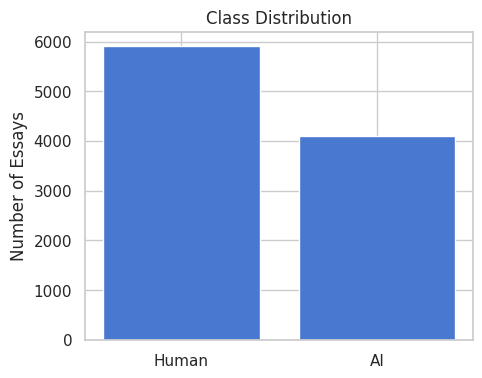


[2] Text length analysis

Word Count stats:
             mean  median  min  max    std
label_name                                
AI          228.5   220.0    2  456  114.0
Human       175.9   172.0   62  312   41.6

Character Count stats:
              mean  median  min   max    std
label_name                                  
AI          1540.4  1538.5   57  3592  729.2
Human       1202.7  1180.0  422  1956  289.8


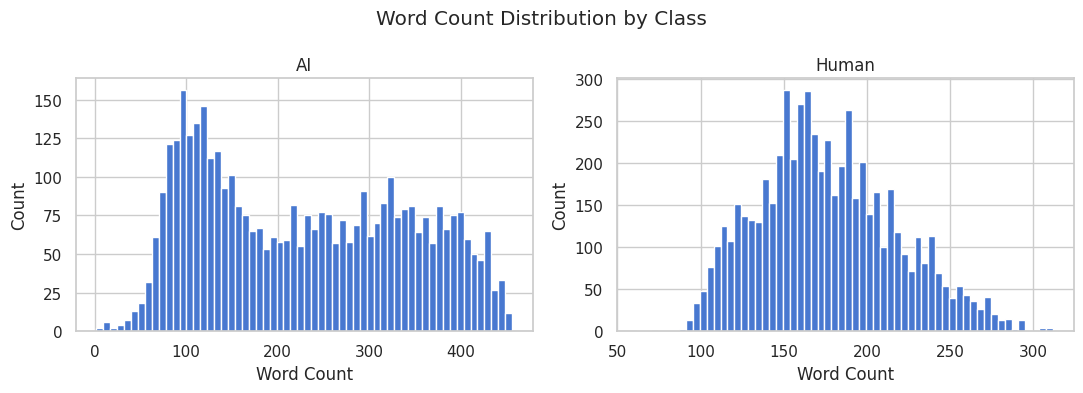

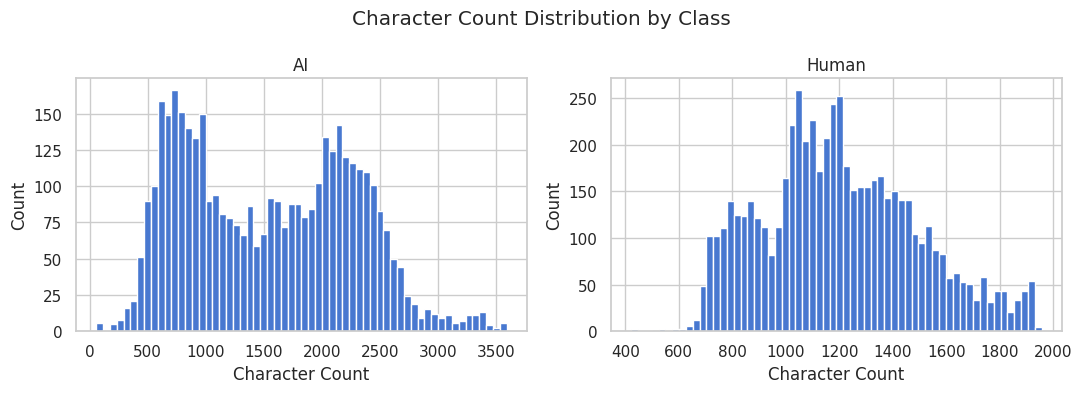

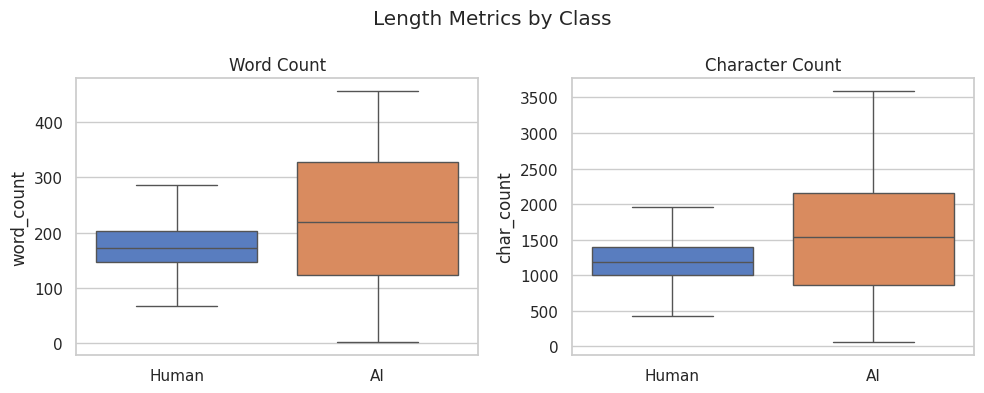


[3] Vocabulary metrics

Type-Token Ratio stats:
             mean  median    min    max    std
label_name                                    
AI          0.612   0.671  0.020  1.000  0.273
Human       0.647   0.648  0.417  0.846  0.059

Avg Word Length (chars) stats:
             mean  median    min      max    std
label_name                                      
AI          6.010   5.892  2.818  293.000  5.153
Human       5.847   5.845  3.782    7.922  0.423

Avg Sentence Length (words) stats:
              mean  median    min    max     std
label_name                                      
AI          26.367  20.667  1.000  429.0  29.060
Human       19.596  19.143  5.167   44.8   4.333


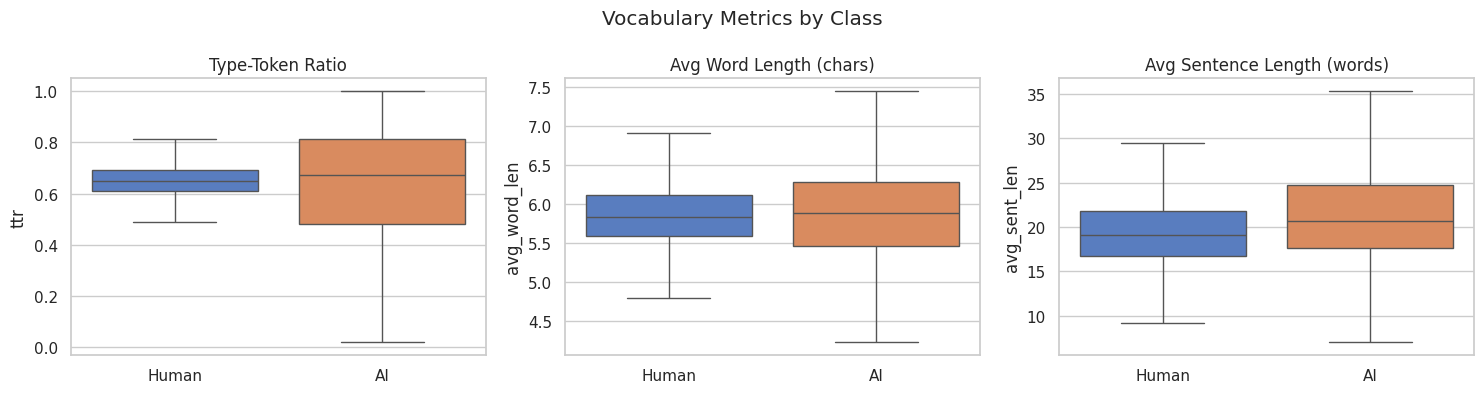

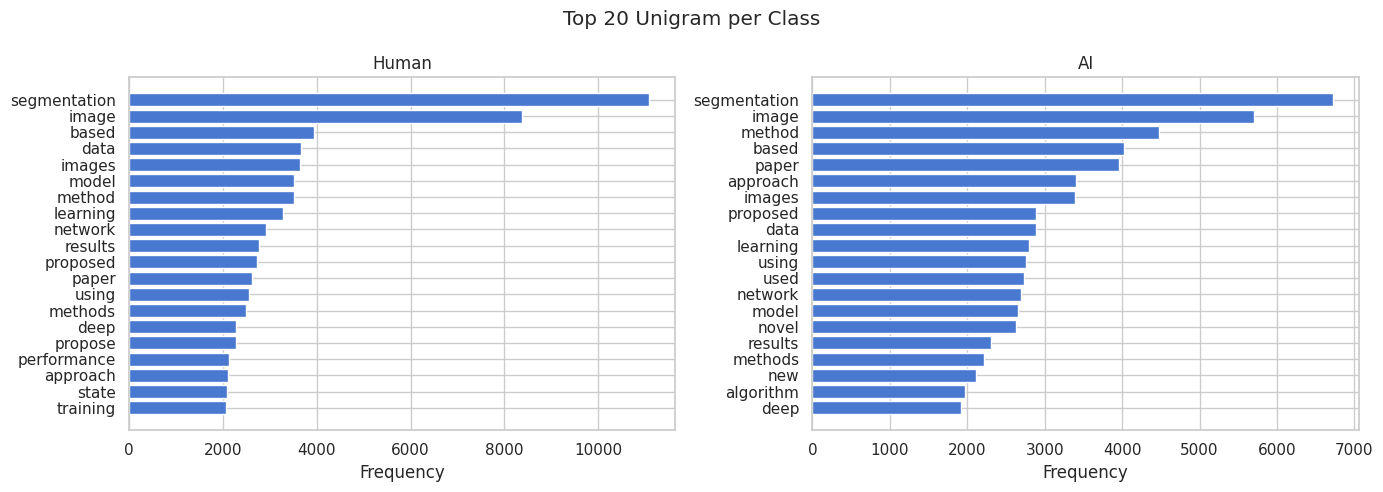

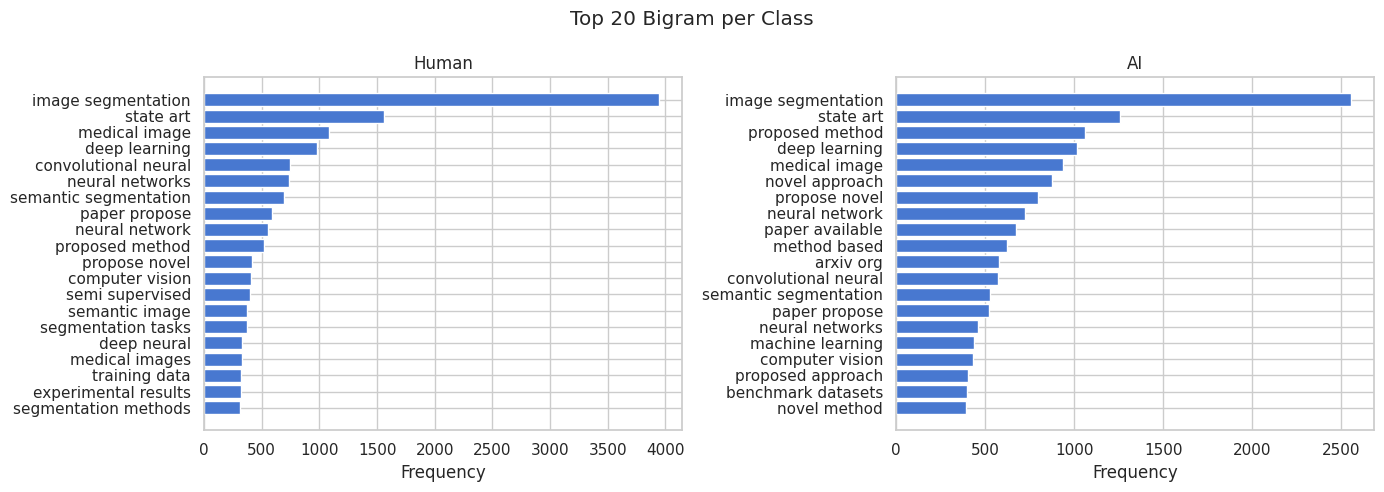


[5] Punctuation and formatting

Punctuation per 1000 chars stats:
             mean  median    std
label_name                      
AI          2.224   1.804  2.359
Human       2.855   2.291  2.177

Paragraph Count stats:
            mean  median  std
label_name                   
AI           1.0     1.0  0.0
Human        1.0     1.0  0.0


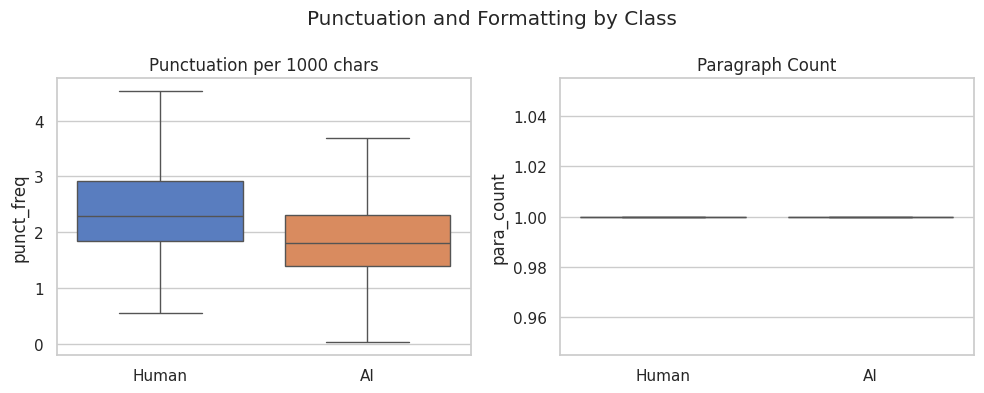

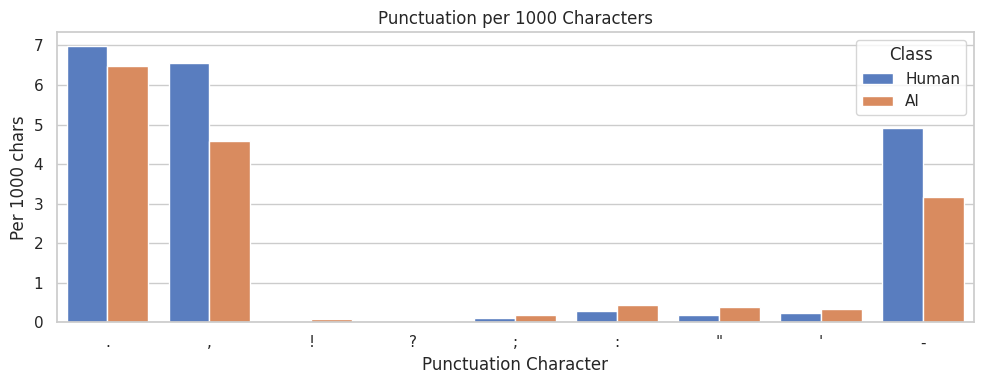

In [ ]:
save_path="results/eda_raid"

df=cleanData(df=raid_df, path=None, text_col_name="generation", label_col_name="model")
raid_df=balanceClasses(df, class_weight={0:0.59, 1:0.41}, total_samples=10000)
df=runAnalysis(raid_df)
plotClassDist(df,      'raid_class_distribution', save_path=save_path)
plotLengthAnalysis(df, 'raid_length_analysis'   , save_path=save_path)
plotVocabMetrics(df,   "raid_vocab_metrics"     , save_path=save_path)
plotTopTermsUnigram(df,'raid_unigram'           , save_path=save_path)
plotTopTermsBigram(df, 'raid_bigram'            , save_path=save_path)
plotFormatting(df,     'raid_formatting'        , save_path=save_path)

## Classification Model Using RoBERTa
- RoBERTa as encoder.
- Simple linear layer as classifier

In [21]:
class ClassificationHead(nn.Module):
  def __init__(self, encoder):
    super().__init__()
    self.roberta=encoder
    self.linear=nn.Sequential(nn.Linear(768, 2))

  def forward(self, ids, mask):
    outputs = self.roberta(input_ids=ids, attention_mask=mask)
    cls_emb = outputs.last_hidden_state[:, 0]
    logits = self.linear(cls_emb)
    return logits, cls_emb

In [22]:
class ingestionPipeline():
    def __init__(self,model_link='FacebookAI/roberta-base', device=device):
      self.model_link=model_link
      self.device=device
      self.tokenizer=AutoTokenizer.from_pretrained(model_link)
      self.collator=DataCollatorWithPadding(tokenizer=self.tokenizer)
      self.encoder=AutoModel.from_pretrained(model_link)

    def initializeModel(self, load_path=None):
      self.tokenizer=AutoTokenizer.from_pretrained(self.model_link)
      self.collator=DataCollatorWithPadding(tokenizer=self.tokenizer)
      self.encoder=AutoModel.from_pretrained(self.model_link)
      self.model=ClassificationHead(self.encoder)
      if load_path:
        weights=torch.load(load_path)
        self.model.load_state_dict(weights)
      self.model.to(self.device)

    def initializeLora(self, r=8, alpha=16, target_mods=["query", "value"], dropout=0.1, lora_path=None):
      self.model = ClassificationHead(self.encoder)

      lora_config = LoraConfig(r=r,lora_alpha=alpha,target_modules=target_mods,lora_dropout=dropout)

      self.model.roberta = get_peft_model(self.model.roberta, lora_config)
      if lora_path:
        self.model.load_state_dict(torch.load(lora_path))
      self.model.to(self.device)
      self.model.roberta.print_trainable_parameters()

    def tokenize(self,batch):
      text=batch['text']
      return self.tokenizer(text, truncation=True, max_length=512)

In [ ]:
IP=ingestionPipeline()

### Training and Evaluation CE Loss

In [23]:
def train(data, model, loss_fn, optimizer,device, epoch, num_epochs):

  size = len(data.dataset)
  num_batches = len(data)
  model.train()
  total_loss = 0
  correct = 0

  for batch_idx, batch in enumerate(data):
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)
      optimizer.zero_grad()
      logits, cls_emb = model(input_ids, attention_mask)
      loss = loss_fn(logits, labels)
      loss.backward()
      torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
      optimizer.step()
      total_loss += loss.item()
      correct += (logits.argmax(dim=1) == labels).sum().item()
      if batch_idx % 100 == 0:
          print(f"  Batch {batch_idx}/{num_batches} — Loss: {loss.item():.4f}")

  avg_loss = total_loss / num_batches
  accuracy = correct / size
  print(f"Epoch {epoch+1}/{num_epochs} — Avg Loss: {avg_loss:.4f}, Train Acc: {accuracy:.4f}")
  return avg_loss, accuracy

In [24]:
def evaluate(dataloader, model, device, metrics_path):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    loss_fn=nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits, _ = model(input_ids, attention_mask)
            loss = loss_fn(logits, labels)

            probs = torch.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    all_probs = np.array(all_probs)
    print(f"Eval Loss: {avg_loss:.4f}")
    genMetrics(all_labels, all_preds, all_probs, metrics_path)
    return avg_loss

In [25]:
def trainer(train_data, num_epochs, ingest_pipe, save_path, device, lora=False, lora_config={}, frozen_bert=False):
  if lora:
    ingest_pipe.initializeLora(**lora_config)
    model=ingest_pipe.model
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4, weight_decay=0.01)

  else:
    ingest_pipe.initializeModel()
    model=ingest_pipe.model
    loss_fn = nn.CrossEntropyLoss()
    if frozen_bert:
      for param in model.roberta.parameters():
        param.requires_grad = False

      optimizer = torch.optim.AdamW(
                  model.linear.parameters(),
                  lr=1e-3,
                  weight_decay=0.01
                    )
    else:
      optimizer=torch.optim.AdamW([
      {"params": model.roberta.parameters(), "lr": 2e-5},
      {"params": model.linear.parameters(), "lr": 1e-3},
      ], weight_decay=0.01)

  for epoch in range(num_epochs):
      train_loss, train_acc = train(train_data, model, loss_fn, optimizer, device, epoch, num_epochs)

  torch.save(model.state_dict(), save_path)


## Data Pipeline Initialization

In [ ]:
train_loader, val_loader, test_loader=DataLoaderPipeline(csv_path=DATA_PATH,
                                                         val_size=0.1,
                                                         test_size=0.2,
                                                         use_cols=['text', 'label'],
                                                         tokenizer=IP.tokenize,
                                                         format_cols=['input_ids', 'attention_mask', 'label'],
                                                         batch_size=32,
                                                         collator=IP.collator,
                                                         num_workers=0,
                                                         )

In [ ]:
raid_test_120=DataLoaderPipeline(csv_path=RAID_120_PATH,
                                 split=False,
                                 use_cols=['text', 'label'],
                                 tokenizer=IP.tokenize,
                                 format_cols=['input_ids', 'attention_mask', 'label'],
                                 batch_size=32,
                                 collator=IP.collator,
                                 num_workers=0,
                                 balance_data=True,
                                 balancer_kwargs={'class_weight': {0:0.59, 1:0.41}, 'total_samples':10000},
                                 binarize_label=True,
                                 label_col='model',
                                 text_col='generation'
                                 )

In [ ]:
raid_train_1M, raid_val_1M, raid_test_1M=DataLoaderPipeline(csv_path=RAID_1000_PATH,
                                                            split=True,
                                                            val_size=0.1,
                                                            test_size=0.2,
                                                            use_cols=['text', 'label'],
                                                            tokenizer=IP.tokenize,
                                                            format_cols=['input_ids', 'attention_mask', 'label'],
                                                            batch_size=32,
                                                            collator=IP.collator,
                                                            num_workers=0,
                                                            balance_data=True,
                                                            balancer_kwargs={'class_weight': {0:0.29, 1:0.71}, 'total_samples':100000},
                                                            binarize_label=True,
                                                            label_col='model',
                                                            text_col='generation'
                                                            )

## RoBERTa Finetuning on Kaggle

### Train

In [ ]:
trainer(train_loader,4, IP, "/content/drive/MyDrive/roberta_full_ft.pt",device)

### Load Saved Model and Evaluate

- RoBERTa full trained on Kaggle dataset

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




########################################### RoBERTa Full Trained on Kaggle ###########################################


|------------------Kaggle------------------|
Eval Loss: 0.0029
Accuracy= 99.95%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3220
           1       1.00      1.00      1.00      2236

    accuracy                           1.00      5456
   macro avg       1.00      1.00      1.00      5456
weighted avg       1.00      1.00      1.00      5456



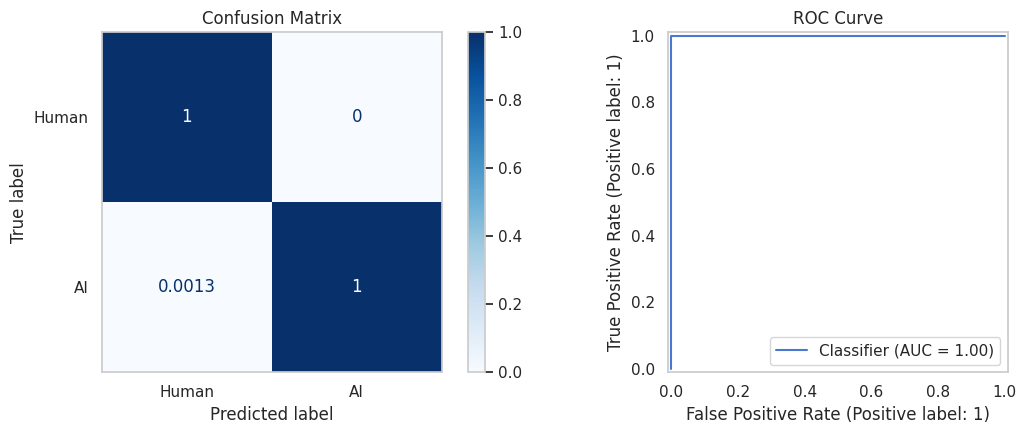



|------------------RAID (OOD)------------------|
Eval Loss: 7.9585
Accuracy= 42.79%
              precision    recall  f1-score   support

           0       0.59      0.10      0.17      5900
           1       0.41      0.90      0.56      4100

    accuracy                           0.43     10000
   macro avg       0.50      0.50      0.37     10000
weighted avg       0.52      0.43      0.33     10000



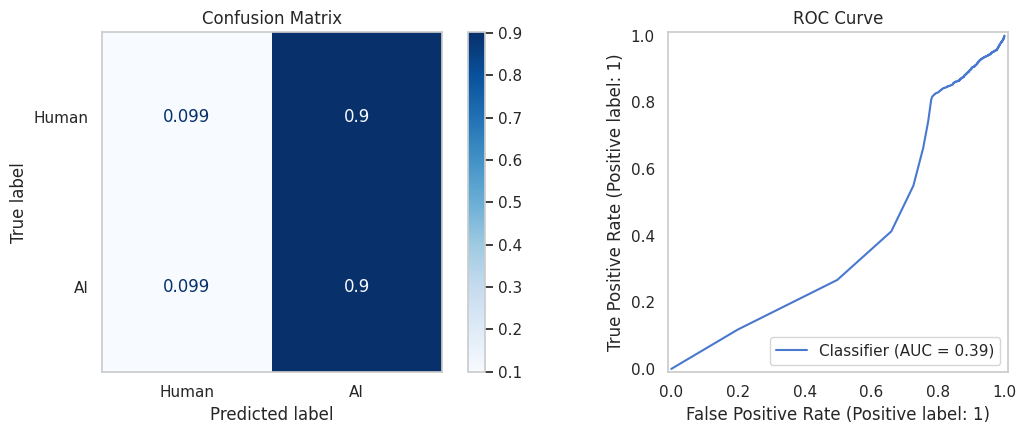

7.9585368916899

In [39]:
IP.initializeModel(load_path="/content/drive/MyDrive/roberta_full_ft.pt")

print("\n\n########################################### RoBERTa Full Trained on Kaggle ###########################################")

print("\n\n|------------------Kaggle------------------|")
evaluate(test_loader, IP.model, device, "results/roberta_kaggle_kaggle")

print("\n\n|------------------RAID (OOD)------------------|")
evaluate(raid_test_120, IP.model, device, "results/roberta_kaggle_raid")

## RoBERTa Finetuning on RAID

### Train

In [ ]:
trainer(raid_train_1M, 4, IP, "/content/drive/MyDrive/roberta_full_RAID_ft.pt",device)

### Load Trained Model and Evaluate

- RoBERTa trained on RAID

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




########################################### RoBERTa Full Trained on RAID ###########################################


|------------------Kaggle (OOD)------------------|
Eval Loss: 5.8154
Accuracy= 50.22%
              precision    recall  f1-score   support

           0       1.00      0.16      0.27      3220
           1       0.45      1.00      0.62      2236

    accuracy                           0.50      5456
   macro avg       0.73      0.58      0.45      5456
weighted avg       0.78      0.50      0.41      5456



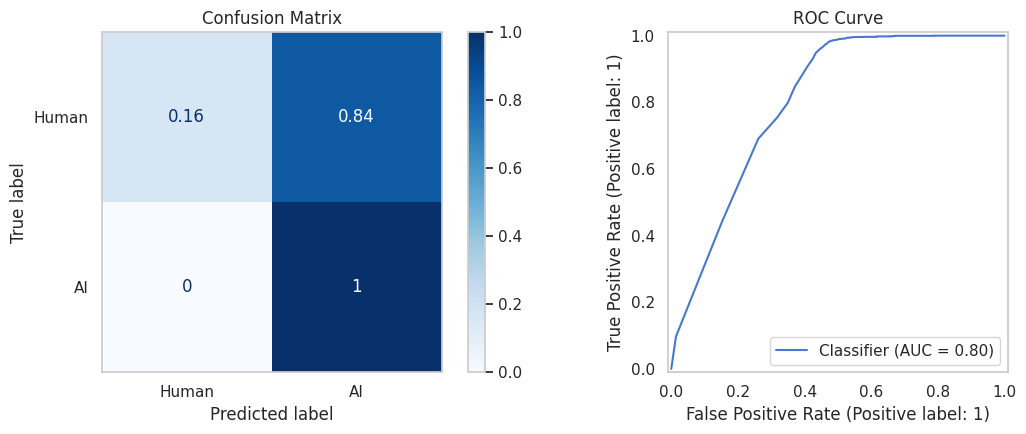



|------------------RAID------------------|
Eval Loss: 0.3071
Accuracy= 94.06%
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      5800
           1       0.94      0.98      0.96     14200

    accuracy                           0.94     20000
   macro avg       0.94      0.91      0.93     20000
weighted avg       0.94      0.94      0.94     20000



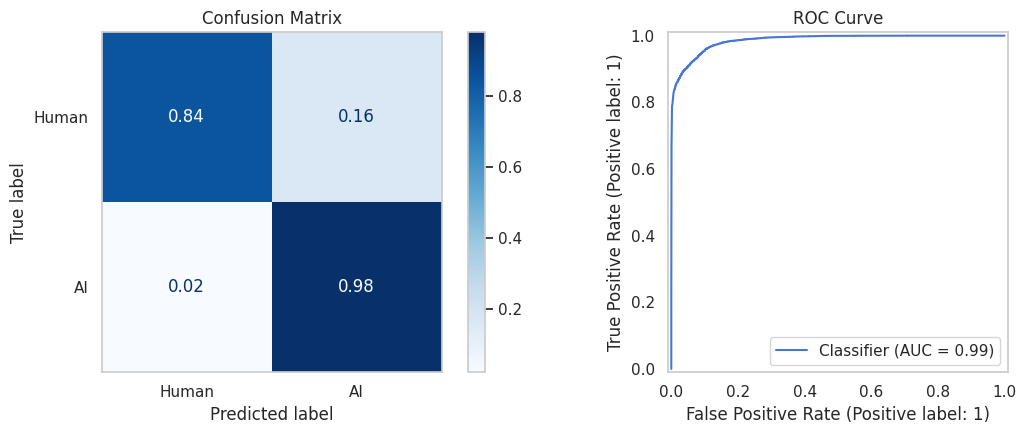

0.3071460508417571

In [40]:
IP.initializeModel(load_path="/content/drive/MyDrive/roberta_full_RAID_ft.pt")

print("\n\n########################################### RoBERTa Full Trained on RAID ###########################################")

print("\n\n|------------------Kaggle (OOD)------------------|")
evaluate(test_loader, IP.model, device, "results/roberta_raid_kaggle")

print("\n\n|------------------RAID------------------|")
evaluate(raid_test_1M, IP.model, device, "results/roberta_raid_raid")


## LoRA Finetuning on Kaggle

### Train

In [ ]:
trainer(train_loader, 4, IP, "/content/drive/MyDrive/roberta_lora_ft.pt",device, lora=True)

### Load Saved Model and Evaluate

- RoBERTa LoRA trained on kaggle

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 294,912 || all params: 124,940,544 || trainable%: 0.2360


########################################### RoBERTa LoRA Trained on Kaggle ###########################################


|------------------Kaggle------------------|
Eval Loss: 0.0416
Accuracy= 99.16%
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3220
           1       0.98      1.00      0.99      2236

    accuracy                           0.99      5456
   macro avg       0.99      0.99      0.99      5456
weighted avg       0.99      0.99      0.99      5456



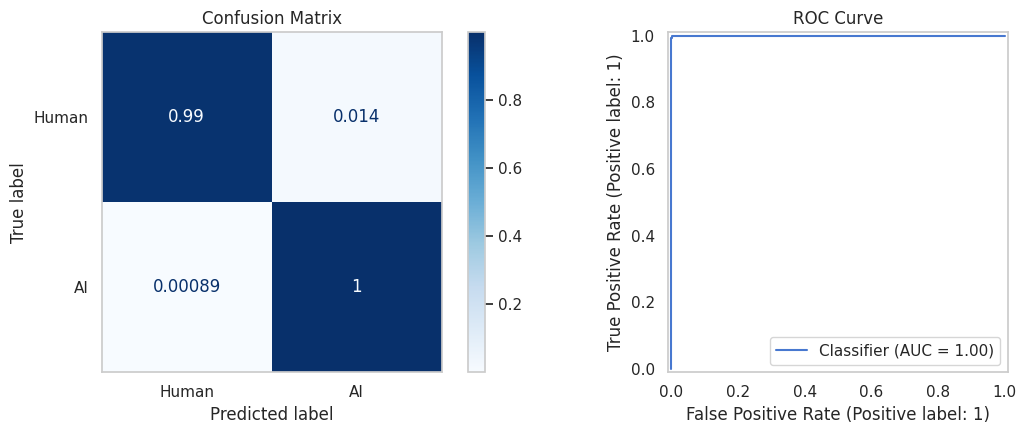



|------------------RAID (OOD)------------------|
Eval Loss: 4.8512
Accuracy= 40.97%
              precision    recall  f1-score   support

           0       0.50      0.04      0.07      5900
           1       0.41      0.94      0.57      4100

    accuracy                           0.41     10000
   macro avg       0.45      0.49      0.32     10000
weighted avg       0.46      0.41      0.28     10000



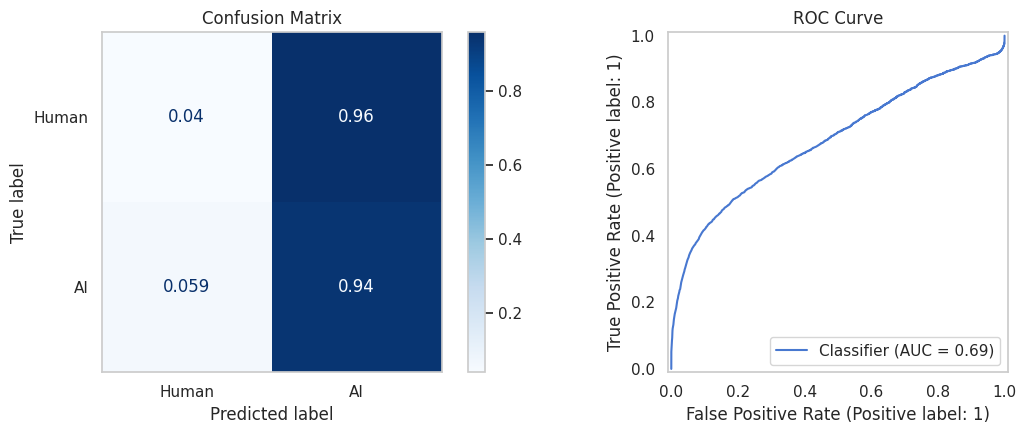

4.851223083037047

In [42]:
IP.initializeLora(lora_path="/content/drive/MyDrive/roberta_lora_ft.pt")
print("\n\n########################################### RoBERTa LoRA Trained on Kaggle ###########################################")

print("\n\n|------------------Kaggle------------------|")
evaluate(test_loader, IP.model, device, "results/lora_kaggle_kaggle_8")

print("\n\n|------------------RAID (OOD)------------------|")
evaluate(raid_test_120, IP.model,device,"results/lora_kaggle_raid_8")

## LoRA Finetuning on RAID

### Train

In [ ]:
trainer(raid_train_1M, 4, IP, "/content/drive/MyDrive/roberta_lora_ft_RAID.pt", device, lora=True)

### Load Trained Model

- RoBERTa LoRA trained on RAID

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 294,912 || all params: 124,940,544 || trainable%: 0.2360


########################################### RoBERTa LoRA Trained on RAID ###########################################


|------------------Kaggle (OOD)------------------|
Eval Loss: 3.1229
Accuracy= 56.89%
              precision    recall  f1-score   support

           0       0.99      0.27      0.43      3220
           1       0.49      0.99      0.65      2236

    accuracy                           0.57      5456
   macro avg       0.74      0.63      0.54      5456
weighted avg       0.78      0.57      0.52      5456



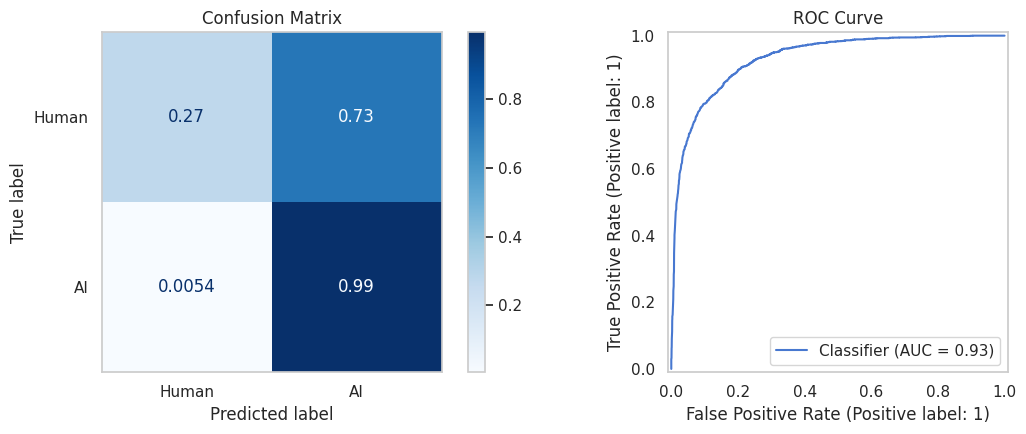



|------------------RAID------------------|
Eval Loss: 0.2087
Accuracy= 93.62%
              precision    recall  f1-score   support

           0       0.96      0.81      0.88      5800
           1       0.93      0.99      0.96     14200

    accuracy                           0.94     20000
   macro avg       0.95      0.90      0.92     20000
weighted avg       0.94      0.94      0.93     20000



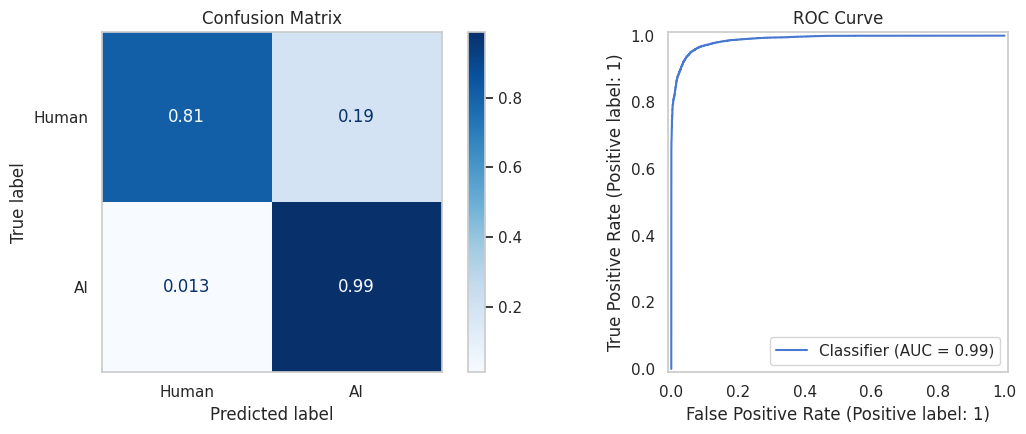

0.20868215056154876

In [43]:
IP.initializeLora(lora_path="/content/drive/MyDrive/roberta_lora_ft_RAID.pt")
print("\n\n########################################### RoBERTa LoRA Trained on RAID ###########################################")

print("\n\n|------------------Kaggle (OOD)------------------|")
evaluate(test_loader, IP.model, device, "results/lora_raid_kaggle_8")

print("\n\n|------------------RAID------------------|")
evaluate(raid_test_1M, IP.model, device, "results/lora_raid_raid_8")

## LoRA Trained on RAID
- $r=4$, $\alpha=8$

### Train

In [ ]:
trainer(raid_train_1M, 4, IP, "/content/drive/MyDrive/roberta_lora_ft_RAID_4.pt", device, lora=True, lora_config={"r":4, "alpha": 8})

### Load Trained Model

- RoBERTa LoRA trained on RAID
- $r=4$, $\alpha=8$

trainable params: 147,456 || all params: 124,793,088 || trainable%: 0.1182


########################################### RoBERTa LoRA Trained on RAID (r=4,alpha=8) ###########################################


|------------------Kaggle (OOD)------------------|
Eval Loss: 2.5711
Accuracy= 59.90%
              precision    recall  f1-score   support

           0       1.00      0.32      0.49      3220
           1       0.51      1.00      0.67      2236

    accuracy                           0.60      5456
   macro avg       0.75      0.66      0.58      5456
weighted avg       0.80      0.60      0.56      5456



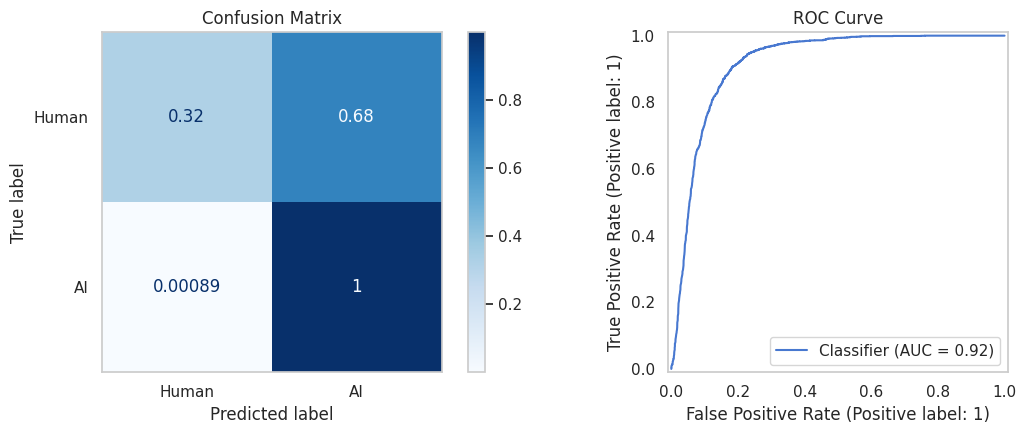



|------------------RAID------------------|
Eval Loss: 0.1615
Accuracy= 93.94%
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      5800
           1       0.94      0.98      0.96     14200

    accuracy                           0.94     20000
   macro avg       0.94      0.91      0.92     20000
weighted avg       0.94      0.94      0.94     20000



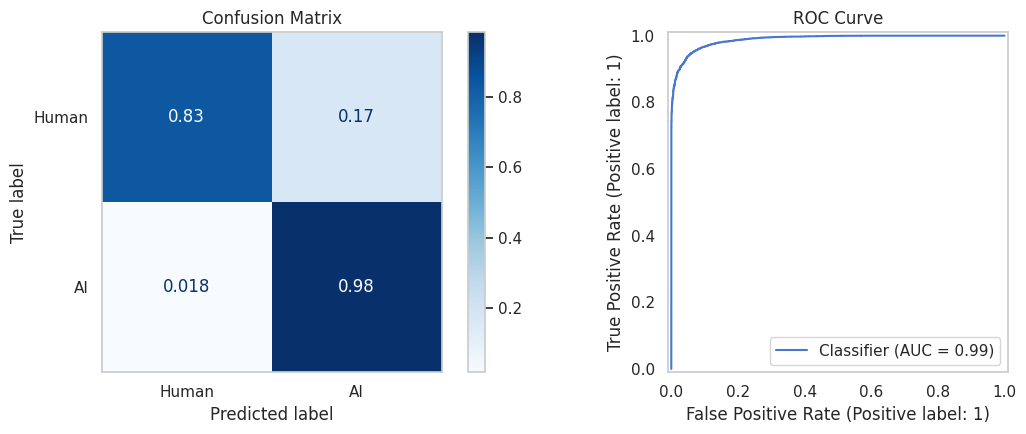

0.16154381539151072

In [46]:
IP.initializeLora(r=4, alpha=8,lora_path="/content/drive/MyDrive/roberta_lora_ft_RAID_4.pt")

print("\n\n########################################### RoBERTa LoRA Trained on RAID (r=4,alpha=8) ###########################################")


print("\n\n|------------------Kaggle (OOD)------------------|")

evaluate(test_loader, IP.model, device, "results/lora_raid_kaggle_4")

print("\n\n|------------------RAID------------------|")

evaluate(raid_test_1M, IP.model, device, "results/lora_raid_raid_4")

## LoRA Trained on RAID
- $r=2$, $\alpha=4$

### Train

In [49]:
trainer(raid_train_1M, 4, IP, "/content/drive/MyDrive/roberta_lora_ft_RAID_2.pt", device, lora=True, lora_config={"r":2, "alpha": 4})

trainable params: 73,728 || all params: 124,719,360 || trainable%: 0.0591
  Batch 0/2188 — Loss: 0.8002
  Batch 100/2188 — Loss: 0.4889
  Batch 200/2188 — Loss: 0.2997
  Batch 300/2188 — Loss: 0.3295
  Batch 400/2188 — Loss: 0.2873
  Batch 500/2188 — Loss: 0.1414
  Batch 600/2188 — Loss: 0.3305
  Batch 700/2188 — Loss: 0.2418
  Batch 800/2188 — Loss: 0.2183
  Batch 900/2188 — Loss: 0.2825
  Batch 1000/2188 — Loss: 0.4499
  Batch 1100/2188 — Loss: 0.2035
  Batch 1200/2188 — Loss: 0.1612
  Batch 1300/2188 — Loss: 0.1207
  Batch 1400/2188 — Loss: 0.2632
  Batch 1500/2188 — Loss: 0.2433
  Batch 1600/2188 — Loss: 0.3193
  Batch 1700/2188 — Loss: 0.1919
  Batch 1800/2188 — Loss: 0.1332
  Batch 1900/2188 — Loss: 0.3194
  Batch 2000/2188 — Loss: 0.2814
  Batch 2100/2188 — Loss: 0.2132
Epoch 1/4 — Avg Loss: 0.2512, Train Acc: 0.8864
  Batch 0/2188 — Loss: 0.1247
  Batch 100/2188 — Loss: 0.3543
  Batch 200/2188 — Loss: 0.2454
  Batch 300/2188 — Loss: 0.2016
  Batch 400/2188 — Loss: 0.1693
  Batc

### Load Trained Model

- RoBERTa LoRA trained on RAID
- $r=2$, $\alpha=4$

trainable params: 73,728 || all params: 124,719,360 || trainable%: 0.0591


########################################### RoBERTa LoRA Trained on RAID (r=2,alpha=4) ###########################################


|------------------Kaggle (OOD)------------------|
Eval Loss: 3.8781
Accuracy= 51.98%
              precision    recall  f1-score   support

           0       1.00      0.19      0.31      3220
           1       0.46      1.00      0.63      2236

    accuracy                           0.52      5456
   macro avg       0.73      0.59      0.47      5456
weighted avg       0.78      0.52      0.44      5456



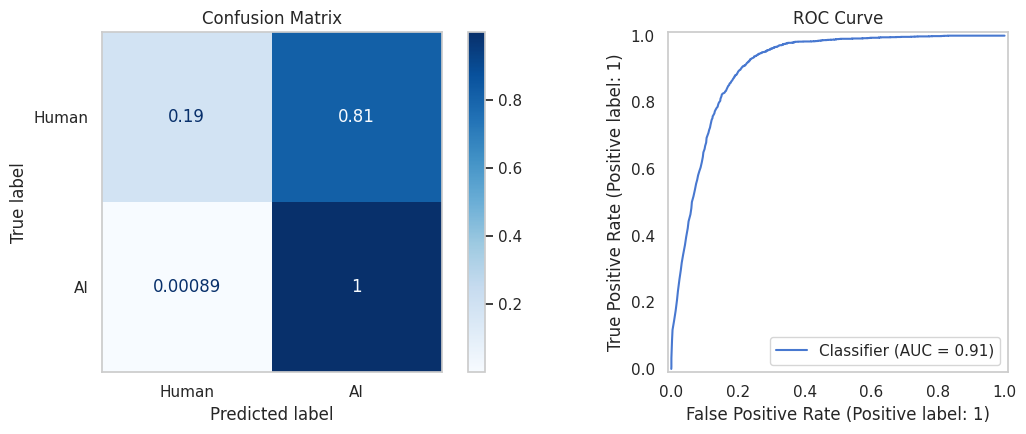



|------------------RAID------------------|
Eval Loss: 0.3109
Accuracy= 89.81%
              precision    recall  f1-score   support

           0       0.97      0.67      0.79      5800
           1       0.88      0.99      0.93     14200

    accuracy                           0.90     20000
   macro avg       0.92      0.83      0.86     20000
weighted avg       0.91      0.90      0.89     20000



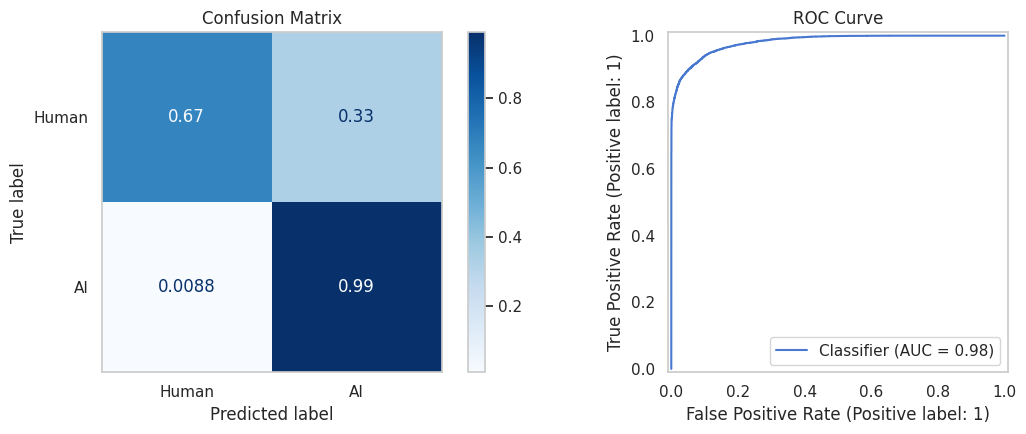

0.3109480977877975

In [51]:
IP.initializeLora(r=2, alpha=4,lora_path="/content/drive/MyDrive/roberta_lora_ft_RAID_2.pt")

print("\n\n########################################### RoBERTa LoRA Trained on RAID (r=2,alpha=4) ###########################################")


print("\n\n|------------------Kaggle (OOD)------------------|")

evaluate(test_loader, IP.model, device, "results/lora_raid_kaggle_2")

print("\n\n|------------------RAID------------------|")

evaluate(raid_test_1M, IP.model, device, "results/lora_raid_raid_2")

## Frozen RoBERTa with classification head


In [ ]:
trainer(raid_train_1M, 4, IP, "/content/drive/MyDrive/roberta_frozen_RAID.pt", device, frozen_bert=True)

### Load Trained Model

- RoBERTa frozen

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




########################################### RoBERTa Frozen Trained on RAID ###########################################


|------------------Kaggle (OOD)------------------|
Eval Loss: 1.1459
Accuracy= 41.29%
              precision    recall  f1-score   support

           0       1.00      0.01      0.01      3220
           1       0.41      1.00      0.58      2236

    accuracy                           0.41      5456
   macro avg       0.71      0.50      0.30      5456
weighted avg       0.76      0.41      0.24      5456



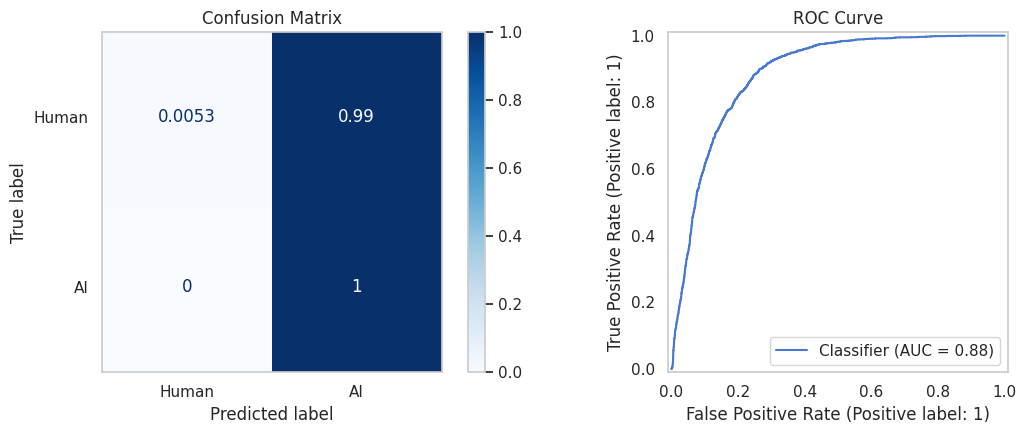



|------------------RAID------------------|
Eval Loss: 0.3896
Accuracy= 81.47%
              precision    recall  f1-score   support

           0       0.93      0.39      0.55      5800
           1       0.80      0.99      0.88     14200

    accuracy                           0.81     20000
   macro avg       0.86      0.69      0.72     20000
weighted avg       0.84      0.81      0.79     20000



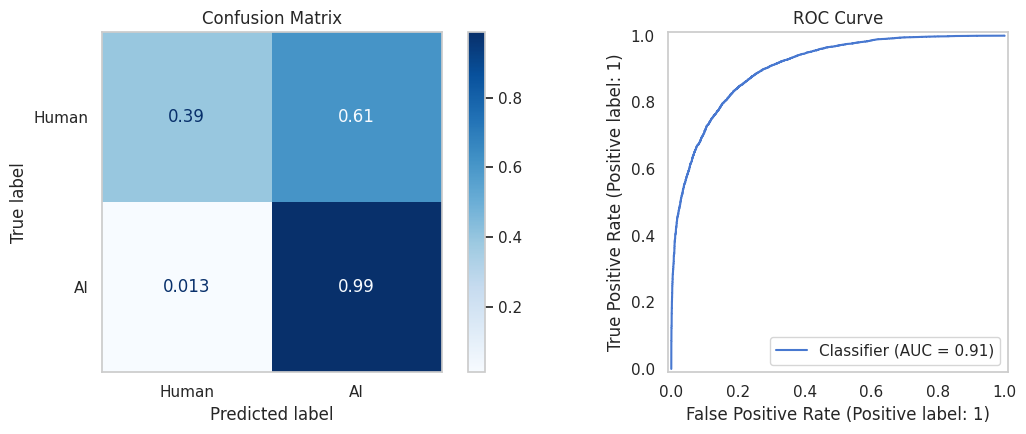

0.3895972588300705

In [48]:
IP.initializeModel(load_path="/content/drive/MyDrive/roberta_frozen_RAID.pt")
print("\n\n########################################### RoBERTa Frozen Trained on RAID ###########################################")

print("\n\n|------------------Kaggle (OOD)------------------|")
evaluate(test_loader, IP.model, device, "results/frozen_raid_kaggle")

print("\n\n|------------------RAID------------------|")
evaluate(raid_test_1M, IP.model, device, "results/frozen_raid_raid")


## Zip and Download Results

In [52]:
import shutil
shutil.make_archive('/content/results', 'zip', '/content/results')

from google.colab import files
files.download('/content/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>